# 05. Baseline Credit Risk Modeling

## Objective

- The objective of this notebook is to develop a baseline machine-learning model for predicting loan default using Logistic Regression.
- The model will estimate the probability that a loan applicant defaults based on demographic, financial, employment and credit-related characteristics.
- The baseline model will provide a reference point for evaluating more complex models later in the project.
- Because the target variable is highly imbalanced, model performance will not be evaluated using accuracy alone. ROC-AUC, PR-AUC, precision, recall, F1-score and threshold-based performance will be examined.

In [1]:
# Importing the required libraries.
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,average_precision_score,confusion_matrix, classification_report, roc_curve, precision_recall_curve)

In [2]:
# Loading the structurally cleaned dataset.
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "application_train_structural_cleaned.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
print("\nTarget distribution:")
print(df["TARGET"].value_counts())
print("\nTarget distribution (%):")
print((df["TARGET"].value_counts(normalize=True) * 100).round(2))

Dataset shape: (307511, 105)

Target distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Target distribution (%):
TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64


In [3]:
# Defining features and target.
X=df.drop(columns=["TARGET", "SK_ID_CURR"])
y=df["TARGET"]

print("Feature matrix shape:", X.shape)
print("Target Shape:", y.shape)

print("Target distribution:")
print(y.value_counts())
print("\nTarget Percentage:")
print(y.value_counts(normalize=True)*100)

Feature matrix shape: (307511, 103)
Target Shape: (307511,)
Target distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Target Percentage:
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


In [4]:
# Train-Test Split.
X_train, X_test, y_train, y_test= train_test_split( X, y, test_size=0.20, random_state=42, stratify=y)

print("Training Observations:", X_train.shape[0])
print("Testing Observations:", X_test.shape[0])

print("\nTraining Default Rate:")
print(y_train.mean())

print("\nTesting Default Rate:")
print(y_test.mean())

Training Observations: 246008
Testing Observations: 61503

Training Default Rate:
0.08072908198107379

Testing Default Rate:
0.08072776937710356


In [5]:
# Building the preprocessing pipeline.
numerical_features=X_train.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_features=X_train.select_dtypes(include=["object"]).columns
print("Numerical Features:", len(numerical_features))
print("Categorical Features:", len(categorical_features))

# Numerical Preprocessing
numeric_pipeline=Pipeline(steps=[("imputer", SimpleImputer(strategy="median")),("scaler", StandardScaler())])

# Categorical Preprocessing
categorical_pipeline=Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OneHotEncoder(handle_unknown="ignore",sparse_output=True))])

# Combining both preprocessor into one.
preprocessor=ColumnTransformer(transformers=[("num", numeric_pipeline, numerical_features),("cat", categorical_pipeline, categorical_features)])


Numerical Features: 88
Categorical Features: 15


C:\Users\unive\AppData\Local\Temp\ipykernel_33680\1976232771.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features=X_train.select_dtypes(include=["object"]).columns


In [6]:
# Building the Logistic Regression Pipeline
logistic_pipeline=Pipeline(steps=[("preprocessor", preprocessor),("model", LogisticRegression(max_iter=1000, random_state=42))])

In [7]:
# Training the Baseline Model.
logistic_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](103,)","['NAME_CONTRACT_TYPE','CODE_GENDER','FLAG_OWN_CAR',..., 'AMT_REQ_CREDIT_BUREAU_MON','AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,103
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped

In [8]:
# Checking the model convergence.
logistic_model=logistic_pipeline.named_steps["model"]

print("Number of iterations used:", logistic_model.n_iter_)

Number of iterations used: [86]


In [9]:
# Generating Predictions.
## Classification
y_pred = logistic_pipeline.predict(X_test)

## Probability
y_prob = logistic_pipeline.predict_proba(X_test)[:,1]

pd.Series(y_prob).describe()

count    6.150300e+04
mean     8.041396e-02
std      7.495159e-02
min      6.326982e-12
25%      3.158170e-02
50%      5.594522e-02
75%      1.019975e-01
max      7.573743e-01
dtype: float64

In [10]:
# Classification metrics.
baseline_metrics={"Accuracy":accuracy_score(y_test, y_pred), "Precision":precision_score(y_test, y_pred,zero_division=0), "Recall": recall_score(y_test, y_pred, zero_division=0), "F1 Score":f1_score(y_test, y_pred, zero_division=0), "ROC-AUC":roc_auc_score(y_test, y_prob), "PR-AUC":average_precision_score(y_test, y_prob)}
baseline_metrics

baseline_metrics_df=pd.DataFrame(baseline_metrics.items(), columns=["Metrics", "Score"])
baseline_metrics_df

,Metrics,Score
0,Accuracy,0.919451
1,Precision,0.548673
2,Recall,0.012487
3,F1 Score,0.024419
4,ROC-AUC,0.748019
5,PR-AUC,0.227905


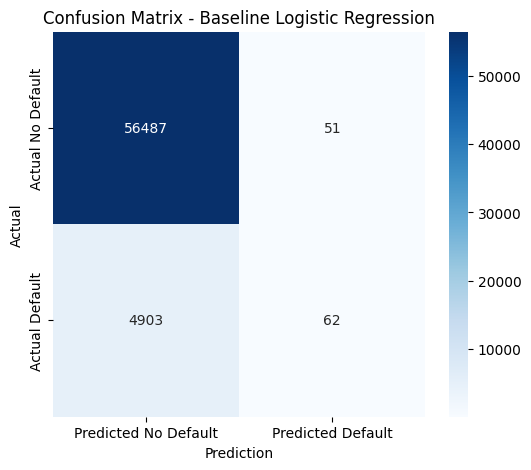

In [11]:
# Confusion Matrix
cm=confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Predicted No Default", "Predicted Default"], yticklabels=["Actual No Default", "Actual Default"])
plt.title("Confusion Matrix - Baseline Logistic Regression")
plt.xlabel("Prediction")
plt.ylabel("Actual")

plt.show()

In [12]:
# Classification Report
print(classification_report(y_test,y_pred, target_names=["No Default", "Default"],zero_division=0))

              precision    recall  f1-score   support

  No Default       0.92      1.00      0.96     56538
     Default       0.55      0.01      0.02      4965

    accuracy                           0.92     61503
   macro avg       0.73      0.51      0.49     61503
weighted avg       0.89      0.92      0.88     61503



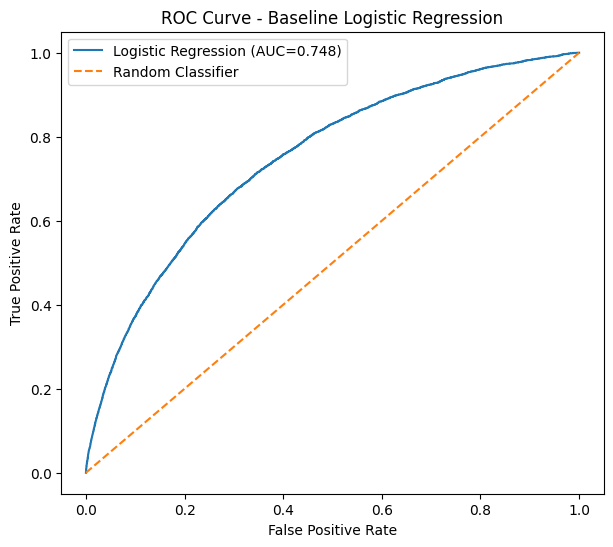

In [13]:
# ROC Curve
fpr,tpr, thresholds=roc_curve(y_test, y_prob)

roc_auc=roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,6))
plt.plot(fpr,tpr, label=f"Logistic Regression (AUC={roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--",label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Baseline Logistic Regression")
plt.legend()

plt.show()

Default prevalence: 0.0807
PR-AUC:0.2279


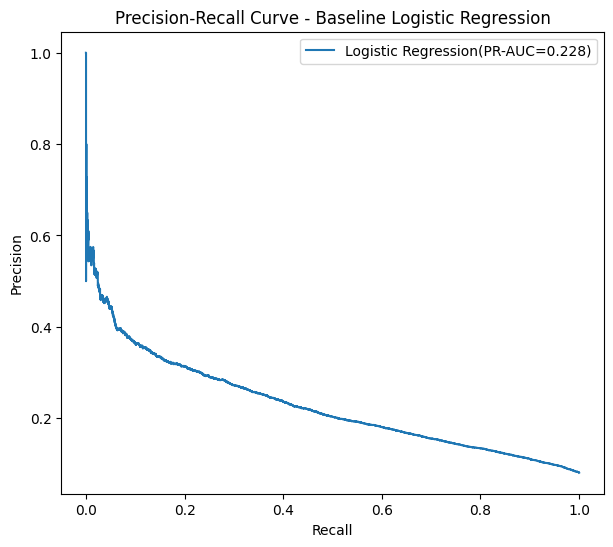

In [14]:
# PR Curve
precision, recall, pr_thresholds=precision_recall_curve(y_test, y_prob)
pr_auc=average_precision_score(y_test, y_prob)

baseline_prevalence=y_test.mean()

print(f"Default prevalence: {baseline_prevalence:.4f}")
print(f"PR-AUC:{pr_auc:.4f}")

plt.figure(figsize=(7,6))
plt.plot(recall, precision, label=f"Logistic Regression(PR-AUC={pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Baseline Logistic Regression")
plt.legend()

plt.show()

Because PR-AUC is sensitive to class prevalence, it should be interpreted relative to the positive-class prevalence. The observed PR-AUC is substantially above the approximately 8.1% prevalence baseline, indicating useful concentration of default observations among higher-risk predictions.

In [15]:
# Threshold Analysis
thresholds_to_test=[0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]
threshold_results=[]

for threshold in thresholds_to_test:
    y_threshold=(y_prob>=threshold).astype(int)
    threshold_results.append({"Threshold":threshold, "Applicants Flagged": y_threshold.sum(), "Flagged %": y_threshold.mean() * 100, "Precision": precision_score(y_test, y_threshold, zero_division=0),"Recall": recall_score(y_test, y_threshold, zero_division=0), "F1":f1_score(y_test, y_threshold, zero_division=0)})
threshold_results=pd.DataFrame(threshold_results)

threshold_results

,Threshold,Applicants Flagged,Flagged %,Precision,Recall,F1
0,0.05,33935,55.176170,0.123707,0.845519,0.215835
1,0.10,15823,25.727200,0.184099,0.586707,0.280258
2,0.15,8176,13.293660,0.238870,0.393353,0.297238
3,0.20,4515,7.341105,0.287265,0.261229,0.273629
4,0.25,2523,4.102239,0.324217,0.164753,0.218483
5,0.30,1447,2.352731,0.363511,0.105942,0.164067
6,0.40,445,0.723542,0.460674,0.041289,0.075786
7,0.50,113,0.183731,0.548673,0.012487,0.024419


### Threshold Analysis

The threshold comparison is exploratory at this stage. No operational threshold is selected because the appropriate credit-risk threshold depends on the relative costs of false positives and false negatives.

A final threshold will be selected later using an explicit risk or business-cost framework.

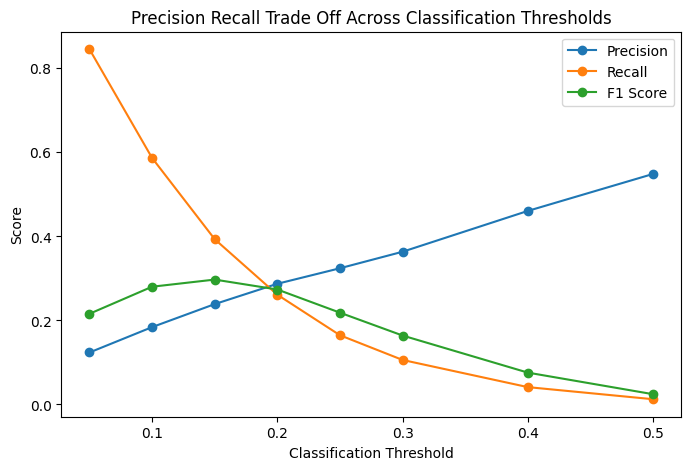

In [16]:
# Visualising the Threshold Tradeoff
plt.figure(figsize=(8,5))

plt.plot(threshold_results["Threshold"], threshold_results["Precision"], marker="o", label="Precision")
plt.plot(threshold_results["Threshold"], threshold_results["Recall"], marker="o", label="Recall")
plt.plot(threshold_results["Threshold"], threshold_results["F1"], marker="o", label="F1 Score")

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision Recall Trade Off Across Classification Thresholds")
plt.legend()

plt.show()

In [17]:
# Baseline Summary Table
baseline_summary = pd.DataFrame({"Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "PR-AUC"],"Score": [accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, zero_division=0), recall_score(y_test, y_pred, zero_division=0), f1_score(y_test, y_pred, zero_division=0), roc_auc_score(y_test, y_prob), average_precision_score(y_test, y_prob)]})

baseline_summary

,Metric,Score
0,Accuracy,0.919451
1,Precision,0.548673
2,Recall,0.012487
3,F1 Score,0.024419
4,ROC-AUC,0.748019
5,PR-AUC,0.227905


## Baseline Model Findings

The standard Logistic Regression model provides a strong linear benchmark for default-risk discrimination.

Because the target variable is substantially imbalanced, the default 0.50 classification threshold produces a conservative classification profile with relatively low recall. Accuracy at this threshold therefore does not provide a sufficient assessment of credit-risk performance.

ROC-AUC and PR-AUC are treated as the primary discrimination metrics, while precision, recall and F1-score are evaluated conditional on the classification threshold.

The baseline model establishes a reference point against which the feature-engineered and nonlinear models developed later in the project can be compared.

## Class-Weighted Logistic Regression

- The baseline Logistic Regression model treats observations from both classes equally during the model estimation. Because loan defaults are relatively rare, a class-weighted version of Logistic Regression is evaluated as a controlled approach to address class imbalance.
- The 'balanced' setting assigns greater weight to minority class based on class frequencies in the training data. 

In [18]:
# Weighted Logistic Pipeline
weighted_logistic_pipeline= Pipeline(steps=[("preprocessor", preprocessor), ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))])

weighted_logistic_pipeline.fit(X_train, y_train)

y_pred_weighted=weighted_logistic_pipeline.predict(X_test)
y_prob_weighted=weighted_logistic_pipeline.predict_proba(X_test)[:,1]

In [19]:
# Evaluating the same metrics for the Weighted Logistic Distribution.
weighted_metrics={"Accuracy":accuracy_score(y_test, y_pred_weighted), "Precision":precision_score(y_test, y_pred_weighted, zero_division=0), "Recall":recall_score(y_test, y_pred_weighted, zero_division=0), "F1 Score":f1_score(y_test, y_pred_weighted, zero_division=0), "ROC-AUC":roc_auc_score(y_test, y_prob_weighted), "PR-AUC":average_precision_score(y_test, y_prob_weighted)}
weighted_metrics_df=pd.DataFrame(weighted_metrics.items(),columns=["Metric", "Weighted Logistic Regression"])

weighted_metrics_df

,Metric,Weighted Logistic Regression
0,Accuracy,0.690535
1,Precision,0.161762
2,Recall,0.677543
3,F1 Score,0.261170
4,ROC-AUC,0.748413
5,PR-AUC,0.228283


In [20]:
# Comparing both the models.
model_comparison=pd.DataFrame({"Metric":["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "PR-AUC"], "Baseline Logistic Regression":[accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, zero_division=0), recall_score(y_test, y_pred, zero_division=0), f1_score(y_test, y_pred, zero_division=0), roc_auc_score(y_test, y_prob), average_precision_score(y_test, y_prob)], "Class-Weighted Logistic Regression":[accuracy_score(y_test, y_pred_weighted), precision_score(y_test, y_pred_weighted, zero_division=0), recall_score(y_test, y_pred_weighted, zero_division=0), f1_score(y_test, y_pred_weighted, zero_division=0), roc_auc_score(y_test, y_prob_weighted), average_precision_score(y_test, y_prob_weighted)]})

model_comparison

,Metric,Baseline Logistic Regression,Class-Weighted Logistic Regression
0,Accuracy,0.919451,0.690535
1,Precision,0.548673,0.161762
2,Recall,0.012487,0.677543
3,F1 Score,0.024419,0.261170
4,ROC-AUC,0.748019,0.748413
5,PR-AUC,0.227905,0.228283


In [21]:
# Threshold Analysis for Class-Weighted Logistic Regression.
pd.Series(y_prob_weighted).describe()

weighted_threshold_results=[]
for threshold in thresholds_to_test:
    y_threshold=(y_prob_weighted>=threshold).astype(int)
    weighted_threshold_results.append({"Threshold":threshold, "Applicants Flagged":int(y_threshold.sum()), "Flagged %": y_threshold.mean()*100, "Precision":precision_score(y_test, y_threshold, zero_division=0), "Recall":recall_score(y_test, y_threshold, zero_division=0), "F1 Score":f1_score(y_test, y_threshold, zero_division=0)})

weighted_threshold_results=pd.DataFrame(weighted_threshold_results)

weighted_threshold_results

,Threshold,Applicants Flagged,Flagged %,Precision,Recall,F1 Score
0,0.05,61371,99.785376,0.080901,1.000000,0.149692
1,0.10,60308,98.057005,0.082162,0.997986,0.151824
2,0.15,57326,93.208461,0.085546,0.987714,0.157455
3,0.20,53016,86.200673,0.091086,0.972608,0.166572
4,0.25,47717,77.584833,0.098686,0.948439,0.178771
5,0.30,41944,68.198299,0.107977,0.912185,0.193097
6,0.40,30636,49.812204,0.131871,0.813696,0.226960
7,0.50,20796,33.812985,0.161762,0.677543,0.261170


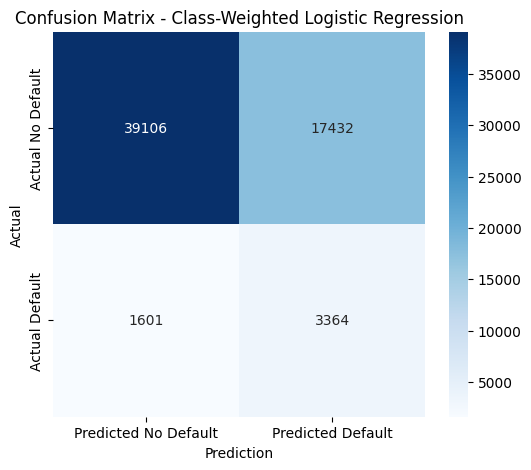

              precision    recall  f1-score   support

  No Default       0.96      0.69      0.80     56538
     Default       0.16      0.68      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503



In [22]:
# Confusion Matrix for Class-Weighted Logistic Regression
cm_weighted=confusion_matrix(y_test, y_pred_weighted)

plt.figure(figsize=(6,5))

sns.heatmap(cm_weighted, annot=True, fmt="d", cmap="Blues", xticklabels=["Predicted No Default", "Predicted Default"], yticklabels=["Actual No Default", "Actual Default"])

plt.title("Confusion Matrix - Class-Weighted Logistic Regression")
plt.xlabel("Prediction")
plt.ylabel("Actual")

plt.show()

# Classification Report for the Class-Weighted Logistic Regression
print(classification_report(y_test, y_pred_weighted, target_names=["No Default", "Default"], zero_division=0))

## Class-Weighted Logistic Regression Findings

Class weighting substantially increases recall at the default 0.50 threshold while reducing precision and overall accuracy. However, ROC-AUC and PR-AUC remain approximately unchanged.

This demonstrates that class weighting primarily changes the model's classification behaviour and decision boundary rather than its underlying ranking ability.

Class weighting changes the fitted model by assigning greater training loss to minority-class observations. Threshold selection subsequently determines the operating point used to convert predicted probabilities into class decisions.

In [23]:
## Baseline Model Comparison.
baseline_model_comparison=pd.DataFrame({"Metric":["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC","PR-AUC"], "Standard Logistic Regression":[accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, zero_division=0), recall_score(y_test, y_pred, zero_division=0), f1_score(y_test, y_pred, zero_division=0), roc_auc_score(y_test, y_prob), average_precision_score(y_test, y_prob)], "Class-Weighted Logistic Regression":[accuracy_score(y_test, y_pred_weighted), precision_score(y_test, y_pred_weighted, zero_division=0), recall_score(y_test, y_pred_weighted, zero_division=0), f1_score(y_test, y_pred_weighted, zero_division=0), roc_auc_score(y_test, y_prob_weighted), average_precision_score(y_test, y_prob_weighted)]})

baseline_model_comparison

,Metric,Standard Logistic Regression,Class-Weighted Logistic Regression
0,Accuracy,0.919451,0.690535
1,Precision,0.548673,0.161762
2,Recall,0.012487,0.677543
3,F1 Score,0.024419,0.261170
4,ROC-AUC,0.748019,0.748413
5,PR-AUC,0.227905,0.228283
